# Porównanie architektur CNN dla rozpoznawania symboli muzycznych
## Multi-head: typ symbolu · wysokość dźwięku · czas trwania

Testujemy cztery architektury na zbiorze `note_dataset`:

| Model | Opis |
|---|---|
| **MusicCNN** | Własna architektura z residual blokami (baseline) |
| **ResNet18** | ResNet-18 z zaadaptowanym pierwszym conv (2 kanały) |
| **EfficientNet-B0** | EfficientNet-B0, pretrenowany na ImageNet |
| **MobileNetV3-Small** | MobileNetV3-Small, pretrenowany na ImageNet |

Każdy model ma **trzy głowice**:
- `head_type` – typ symbolu (33 klasy)
- `head_pos`  – wysokość dźwięku / rel_position (34 klasy; tylko nuty i znaki chromatyczne)
- `head_dur`  – czas trwania nuty (7 klas; ignorowane dla symboli bez wartości rytmicznej)


In [15]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time, re, warnings

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, **kw): return x

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torchvision
import torchvision.models as tv_models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__}  |  torchvision {torchvision.__version__}  |  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch 2.5.1+cu121  |  torchvision 0.20.1+cu121  |  Device: cuda
GPU: NVIDIA GeForce GTX 1050


In [16]:
BASE        = Path('../data/note_dataset')
NOTES_DIR   = BASE / 'notes'
SYMBOLS_DIR = BASE / 'symbols'
TENSORS_DIR = BASE / 'tensors'
RESULTS_DIR = BASE / 'arch_comparison'
RESULTS_DIR.mkdir(exist_ok=True)

IMG_W, IMG_H  = 32, 96
NO_POS_LABEL  = -1

EPOCHS       = 30
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 1e-4
WEIGHT_TYPE  = 1.0    # waga straty dla głowicy typu
WEIGHT_POS   = 0.8    # waga straty dla głowicy pozycji
WEIGHT_DUR   = 0.6    # waga straty dla głowicy czasu trwania
RANDOM_STATE = 42

# Modele do przetrenowania — ustaw False aby pominąć
MODELS_TO_RUN = ['MusicCNN', 'ResNet18', 'EfficientNet_B0', 'MobileNetV3_Small']

# Czy inicjalizować pretrenowane modele wagami ImageNet?
# (wagi pierwszego conv są adaptowane do 2 kanałów)
PRETRAINED = True


## Preprocessing

Dwa kanały wejściowe: **oryginalny obraz** (z liniami pięciolinii) i **obraz po usunięciu linii**.

In [17]:
def to_white_on_black(gray):
    corners = [gray[0, 0], gray[0, -1], gray[-1, 0], gray[-1, -1]]
    if int(np.median(corners)) > 127:
        return cv2.bitwise_not(gray)
    return gray.copy()


def remove_staff_lines(img_wob, scale=2, fill_thresh=0.80):
    h, w = img_wob.shape
    big = cv2.resize(img_wob, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    _, binary = cv2.threshold(big, 127, 255, cv2.THRESH_BINARY)
    H, W = binary.shape
    profile = binary.sum(axis=1) / (W * 255)
    line_rows = set()
    for y, fill in enumerate(profile):
        if fill >= fill_thresh:
            for d in range(-scale, scale + 1):
                if 0 <= y + d < H:
                    line_rows.add(y + d)
    result = binary.copy()
    search = scale * 4
    for y in sorted(line_rows):
        for x in range(W):
            if binary[y, x] == 0:
                continue
            has_symbol = any(
                binary[y2, x] > 0
                for r in range(1, search + 1)
                for y2 in [y - r, y + r]
                if 0 <= y2 < H and y2 not in line_rows
            )
            if not has_symbol:
                result[y, x] = 0
    n_lbl, labels, stats, _ = cv2.connectedComponentsWithStats(result)
    clean = np.zeros_like(result)
    for lbl in range(1, n_lbl):
        if stats[lbl, cv2.CC_STAT_AREA] >= scale * scale * 4:
            clean[labels == lbl] = 255
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(3, scale * 2)))
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, k)
    return cv2.resize(clean, (w, h), interpolation=cv2.INTER_AREA)


def preprocess(img_path):
    """Zwraca tensor (2, H, W): kanal 0 = z liniami, kanal 1 = bez linii."""
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        return np.zeros((2, IMG_H, IMG_W), dtype=np.float32)
    wob = to_white_on_black(gray)
    _, orig_bin = cv2.threshold(wob, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    clean = remove_staff_lines(wob)
    orig = cv2.resize(orig_bin, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    cln  = cv2.resize(clean,    (IMG_W, IMG_H), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
    return np.stack([orig, cln], axis=0)


## Wczytanie danych i kodowanie etykiet

In [18]:
def simplify_duration(dur):
    if pd.isna(dur) or str(dur).strip() == '':
        return 'unknown'
    m = re.match(r'^(\d+)', str(dur).strip())
    if not m:
        return 'other'
    base = int(m.group(1))
    mapping = {1: 'whole', 2: 'half', 4: 'quarter', 8: 'eighth', 16: 'sixteenth', 32: 'thirty_second'}
    return mapping.get(base, 'other')


df_notes   = pd.read_csv(NOTES_DIR   / 'labels.csv')
df_symbols = pd.read_csv(SYMBOLS_DIR / 'labels.csv')
df_notes['img_dir']   = str(NOTES_DIR   / 'images')
df_notes['symbol']    = df_notes['note_type']
df_symbols['img_dir'] = str(SYMBOLS_DIR / 'images')

df = pd.concat([
    df_notes  [['id', 'symbol', 'rel_position', 'duration', 'img_dir']],
    df_symbols[['id', 'symbol', 'rel_position', 'img_dir']],
], ignore_index=True)
df = df[df['rel_position'].isna() | df['rel_position'].between(-20, 20)]

TYPE_CLASSES = sorted(df['symbol'].unique())
type2idx     = {c: i for i, c in enumerate(TYPE_CLASSES)}
NUM_TYPES    = len(TYPE_CLASSES)

HAS_POSITION = {'note1', 'note2', 'note4', 'note8', 'note16',
                'sharp', 'flat', 'natural', 'double_sharp', 'double_flat'}
POS_MASK     = df['symbol'].isin(HAS_POSITION) & df['rel_position'].notna()
valid_pos    = sorted(df.loc[POS_MASK, 'rel_position'].dropna().unique().astype(int))
pos2idx      = {p: i for i, p in enumerate(valid_pos)}
NUM_POS      = len(valid_pos)

df['type_label'] = df['symbol'].map(type2idx)
df['pos_label']  = df.apply(
    lambda r: pos2idx[int(r['rel_position'])]
    if r['symbol'] in HAS_POSITION and pd.notna(r['rel_position'])
       and int(r['rel_position']) in pos2idx
    else NO_POS_LABEL, axis=1)

df['duration_simple'] = df.apply(
    lambda r: simplify_duration(r.get('duration'))
    if 'note' in str(r['symbol']) else 'no_duration', axis=1)

DUR_CLASSES  = sorted(df['duration_simple'].unique())
dur2idx      = {c: i for i, c in enumerate(DUR_CLASSES)}
NUM_DUR      = len(DUR_CLASSES)
NO_DUR_LABEL = dur2idx['no_duration']
df['dur_label'] = df['duration_simple'].map(dur2idx)

print(f"Łącznie: {len(df)} przykładów")
print(f"Typy ({NUM_TYPES}): {TYPE_CLASSES}")
print(f"Pozycje ({NUM_POS}): {valid_pos[0]} .. {valid_pos[-1]}")
print(f"Duration ({NUM_DUR}): {DUR_CLASSES}")
print()
print(df['symbol'].value_counts().to_string())


Łącznie: 19998 przykładów
Typy (33): ['clef_8', 'clef_alto', 'clef_bass', 'clef_tenor', 'clef_treble', 'dot', 'double_sharp', 'flat', 'natural', 'note1', 'note16', 'note2', 'note4', 'note8', 'rest_16th', 'rest_32nd', 'rest_8th', 'rest_half', 'rest_quarter', 'rest_whole', 'sharp', 'time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6', 'time_7', 'time_8', 'time_9', 'time_common', 'time_cut']
Pozycje (34): -15 .. 19
Duration (7): ['eighth', 'half', 'no_duration', 'quarter', 'sixteenth', 'thirty_second', 'whole']

symbol
note4           7415
dot             1629
rest_whole      1266
rest_8th        1053
clef_treble      977
sharp            924
note8            894
note16           795
rest_quarter     731
clef_bass        646
natural          638
note2            638
flat             532
time_4           321
rest_half        296
note1            258
rest_16th        191
time_8           150
clef_8           141
clef_alto        109
time_7            94
clef_tenor        61


## Dataset i DataLoadery

In [19]:
def precompute_all(df, out_dir, force=False):
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)
    skipped = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Precomputing tensors'):
        src    = Path(row['img_dir']) / row['id']
        source = 'notes' if 'notes' in row['img_dir'] else 'symbols'
        dest   = out_dir / f"{source}_{row['id'].replace('.png', '.npy')}"
        if dest.exists() and not force:
            skipped += 1
            continue
        np.save(dest, preprocess(src))
    print(f"Gotowe. Pominięto: {skipped}")


precompute_all(df, TENSORS_DIR)


class MusicDataset(Dataset):
    def __init__(self, df, tensor_dir, augment=False):
        self.df         = df.reset_index(drop=True)
        self.tensor_dir = Path(tensor_dir)
        self.augment    = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        source = 'notes' if 'notes' in row['img_dir'] else 'symbols'
        npy    = self.tensor_dir / f"{source}_{row['id'].replace('.png', '.npy')}"
        tensor = np.load(str(npy))
        if self.augment and np.random.rand() < 0.3:
            tensor = tensor[:, :, ::-1].copy()
        if self.augment and np.random.rand() < 0.3:
            tensor = np.clip(
                tensor + np.random.randn(*tensor.shape).astype(np.float32) * 0.03, 0, 1)
        return (torch.tensor(tensor, dtype=torch.float32),
                torch.tensor(int(row['type_label']), dtype=torch.long),
                torch.tensor(int(row['pos_label']),  dtype=torch.long),
                torch.tensor(int(row['dur_label']),  dtype=torch.long))


df_train, df_val = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
train_ds = MusicDataset(df_train, TENSORS_DIR, augment=True)
val_ds   = MusicDataset(df_val,   TENSORS_DIR, augment=False)

counts  = df_train['type_label'].value_counts()
weights = df_train['type_label'].map(lambda l: 1.0 / counts[l]).values
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")


Precomputing tensors: 100%|██████████| 19998/19998 [00:05<00:00, 3956.92it/s]


Gotowe. Pominięto: 19998
Train: 15998  |  Val: 4000


## Definicje architektur

### Wspólna konwencja
- Wejście: tensor `(B, 2, 96, 32)` — 2 kanały (z liniami / bez linii)
- Każdy model ma identyczne trzy głowice doklejone do wyjścia backbone
- Pretrenowane modele: wagi pierwszego conv adaptowane metodą jasności (`0.299·R + 0.587·G + 0.114·B`)


### 1. MusicCNN — baseline (własna architektura)

In [20]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))


class MusicCNN(nn.Module):
    """Własna architektura z 4 blokami conv+residual. Wejście: (B, 2, 96, 32)."""
    def __init__(self, num_types, num_pos, num_dur):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(2,  32, 3, padding=1, bias=False), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            ResBlock(32),  nn.MaxPool2d(2),
            nn.Conv2d(32,  64, 3, padding=1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            ResBlock(64),  nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            ResBlock(128), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 2)),
        )
        feat = 256 * 4 * 2
        self.head_type = nn.Sequential(
            nn.Flatten(), nn.Linear(feat, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_types))
        self.head_pos = nn.Sequential(
            nn.Flatten(), nn.Linear(feat, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_pos))
        self.head_dur = nn.Sequential(
            nn.Flatten(), nn.Linear(feat, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, num_dur))

    def forward(self, x):
        f = self.backbone(x)
        return self.head_type(f), self.head_pos(f), self.head_dur(f)


### Funkcje pomocnicze dla pretrenowanych modeli

In [21]:
def _adapt_first_conv(old_conv: nn.Conv2d, in_channels: int = 2,
                      use_pretrained_weights: bool = True) -> nn.Conv2d:
    """
    Zamienia Conv2d(3, ...) na Conv2d(in_channels, ...).
    Gdy use_pretrained_weights=True, inicjalizuje wagi przybliżeniem jasności:
        w_new[:, c] = 0.299*R + 0.587*G + 0.114*B  dla każdego nowego kanału c.
    """
    new_conv = nn.Conv2d(
        in_channels, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None,
    )
    if use_pretrained_weights and old_conv.weight is not None:
        with torch.no_grad():
            w = old_conv.weight.data               # (out, 3, kH, kW)
            gray = 0.299 * w[:, 0] + 0.587 * w[:, 1] + 0.114 * w[:, 2]
            for c in range(in_channels):
                new_conv.weight.data[:, c] = gray
    return new_conv


def _make_three_heads(feat: int, num_types: int, num_pos: int,
                      num_dur: int) -> tuple:
    """Zwraca trzy głowice: type, pos, dur."""
    head_type = nn.Sequential(
        nn.Linear(feat, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_types))
    head_pos = nn.Sequential(
        nn.Linear(feat, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_pos))
    head_dur = nn.Sequential(
        nn.Linear(feat, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, num_dur))
    return head_type, head_pos, head_dur


### 2. ResNet-18 Multi-Head

In [22]:
class ResNet18MultiHead(nn.Module):
    """
    ResNet-18 z zaadaptowanym pierwszym conv (3→2 kanały) i trzema głowicami.
    Wymiar cechy po backbone: 512.
    """
    def __init__(self, num_types, num_pos, num_dur, pretrained=True):
        super().__init__()
        try:
            from torchvision.models import resnet18, ResNet18_Weights
            w = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            base = resnet18(weights=w)
        except (ImportError, AttributeError):
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                base = tv_models.resnet18(pretrained=pretrained)

        base.conv1 = _adapt_first_conv(base.conv1, in_channels=2,
                                       use_pretrained_weights=pretrained)
        feat = base.fc.in_features   # 512
        base.fc = nn.Identity()
        self.backbone = base
        self.head_type, self.head_pos, self.head_dur = _make_three_heads(
            feat, num_types, num_pos, num_dur)

    def forward(self, x):
        f = self.backbone(x)
        return self.head_type(f), self.head_pos(f), self.head_dur(f)


### 3. EfficientNet-B0 Multi-Head

In [23]:
class EfficientNetB0MultiHead(nn.Module):
    """
    EfficientNet-B0 z zaadaptowanym pierwszym conv (3→2 kanały) i trzema głowicami.
    Wymiar cechy po backbone: 1280.
    Dla wejść (96×32) sieć zachowuje prawidłowe wymiary dzięki AdaptiveAvgPool2d.
    """
    def __init__(self, num_types, num_pos, num_dur, pretrained=True):
        super().__init__()
        try:
            from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
            w = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
            base = efficientnet_b0(weights=w)
        except (ImportError, AttributeError):
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                base = tv_models.efficientnet_b0(pretrained=pretrained)

        # features[0] to Conv2dNormActivation; features[0][0] to Conv2d
        base.features[0][0] = _adapt_first_conv(base.features[0][0], in_channels=2,
                                                 use_pretrained_weights=pretrained)
        feat = base.classifier[1].in_features  # 1280
        base.classifier = nn.Identity()
        self.backbone = base
        self.head_type, self.head_pos, self.head_dur = _make_three_heads(
            feat, num_types, num_pos, num_dur)

    def forward(self, x):
        f = self.backbone(x)
        return self.head_type(f), self.head_pos(f), self.head_dur(f)


### 4. MobileNetV3-Small Multi-Head

In [28]:
class MobileNetV3SmallMultiHead(nn.Module):
    """
    MobileNetV3-Small z zaadaptowanym pierwszym conv (3→2 kanały) i trzema głowicami.
    Wymiar cechy po backbone: 576.
    """
    def __init__(self, num_types, num_pos, num_dur, pretrained=True):
        super().__init__()
        try:
            from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
            w = MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
            base = mobilenet_v3_small(weights=w)
        except (ImportError, AttributeError):
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                base = tv_models.mobilenet_v3_small(pretrained=pretrained)

        base.features[0][0] = _adapt_first_conv(base.features[0][0], in_channels=2,
                                                 use_pretrained_weights=pretrained)
        feat = base.classifier[0].in_features  # 576
        base.classifier = nn.Identity()
        self.backbone = base
        self.head_type, self.head_pos, self.head_dur = _make_three_heads(
            feat, num_types, num_pos, num_dur)

    def forward(self, x):
        f = self.backbone(x)
        return self.head_type(f), self.head_pos(f), self.head_dur(f)


# ─── Rejestr modeli ──────────────────────────────────────────────────────────
# Aby wyłączyć model, zakomentuj jego linię — zostanie automatycznie pominięty.
MODEL_REGISTRY = {
    # 'MusicCNN':          lambda: MusicCNN(NUM_TYPES, NUM_POS, NUM_DUR),
    'ResNet18':          lambda: ResNet18MultiHead(NUM_TYPES, NUM_POS, NUM_DUR,
                                                   pretrained=PRETRAINED),
    'EfficientNet_B0':   lambda: EfficientNetB0MultiHead(NUM_TYPES, NUM_POS, NUM_DUR,
                                                          pretrained=PRETRAINED),
    'MobileNetV3_Small': lambda: MobileNetV3SmallMultiHead(NUM_TYPES, NUM_POS, NUM_DUR,
                                                            pretrained=PRETRAINED),
}

# Zsynchronizuj MODELS_TO_RUN z rejestrem — jeśli wykomentowałeś model w MODEL_REGISTRY,
# zostanie on automatycznie usunięty z listy bez potrzeby edytowania komórki konfiguracji.
MODELS_TO_RUN = [n for n in MODELS_TO_RUN if n in MODEL_REGISTRY]
print(f"Aktywne modele: {MODELS_TO_RUN}")

# ─── Weryfikacja kształtów wyjść ─────────────────────────────────────────────
print(f"\n{'Model':<25} {'Params':>10}  {'type':>12}  {'pos':>12}  {'dur':>12}")
print('-' * 75)
for name in MODELS_TO_RUN:
    m = MODEL_REGISTRY[name]().to(DEVICE)
    x_t = torch.randn(2, 2, IMG_H, IMG_W).to(DEVICE)
    with torch.no_grad():
        t_out, p_out, d_out = m(x_t)
    n_p = sum(p.numel() for p in m.parameters())
    print(f"{name:<25} {n_p:>10,}  {str(tuple(t_out.shape)):>12}  "
          f"{str(tuple(p_out.shape)):>12}  {str(tuple(d_out.shape)):>12}")
    del m
torch.cuda.empty_cache()


Aktywne modele: ['ResNet18', 'EfficientNet_B0', 'MobileNetV3_Small']

Model                         Params          type           pos           dur
---------------------------------------------------------------------------
ResNet18                  11,519,818       (2, 33)       (2, 34)        (2, 7)
EfficientNet_B0            4,845,222       (2, 33)       (2, 34)        (2, 7)
MobileNetV3_Small          1,314,266       (2, 33)       (2, 34)        (2, 7)


## Trening

Każdy model trenowany jest identycznie:
- Optymalizator: `AdamW` (lr=1e-3, weight_decay=1e-4)
- Scheduler: `CosineAnnealingLR` (T_max=30, eta_min=1e-5)
- Early Stopping: patience=5, min_delta=1e-4
- Ważona próbkowanie po typach symboli (WeightedRandomSampler)
- Augmentacja: losowe odbicie w poziomie + szum gaussowski


In [29]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, crit_t, crit_p, crit_d, optimizer=None):
    """Jedna epoka (train lub val). Zwraca (loss, type_acc, pos_acc, dur_acc)."""
    train = optimizer is not None
    model.train(train)
    total_loss = tc = pc = pt = dc = dt = n = 0
    with torch.set_grad_enabled(train):
        for x, tl, pl, dl in loader:
            x, tl, pl, dl = x.to(DEVICE), tl.to(DEVICE), pl.to(DEVICE), dl.to(DEVICE)
            ot, op, od = model(x)
            loss = (WEIGHT_TYPE * crit_t(ot, tl) +
                    WEIGHT_POS  * crit_p(op, pl) +
                    WEIGHT_DUR  * crit_d(od, dl))
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            tc += (ot.argmax(1) == tl).sum().item()
            mask_p = pl != NO_POS_LABEL
            if mask_p.sum() > 0:
                pc += (op.argmax(1)[mask_p] == pl[mask_p]).sum().item()
                pt += mask_p.sum().item()
            mask_d = dl != NO_DUR_LABEL
            if mask_d.sum() > 0:
                dc += (od.argmax(1)[mask_d] == dl[mask_d]).sum().item()
                dt += mask_d.sum().item()
            n += x.size(0)
    return (total_loss / n,
            tc / n,
            pc / pt if pt > 0 else 0.0,
            dc / dt if dt > 0 else 0.0)


In [30]:
def train_model(name: str, epochs: int = EPOCHS):
    """Trenuje model o podanej nazwie i zapisuje wyniki do RESULTS_DIR."""
    model = MODEL_REGISTRY[name]().to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())

    crit_t = nn.CrossEntropyLoss()
    crit_p = nn.CrossEntropyLoss(ignore_index=NO_POS_LABEL)
    crit_d = nn.CrossEntropyLoss(ignore_index=NO_DUR_LABEL)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    stopper   = EarlyStopping(patience=5, min_delta=1e-4)

    history = {k: [] for k in [
        'loss', 'val_loss', 'type_acc', 'val_type_acc',
        'pos_acc', 'val_pos_acc', 'dur_acc', 'val_dur_acc']}
    best_type_acc = 0.0

    print(f"\n{'='*80}")
    print(f"  {name}  |  {n_params:,} parametrów  |  pretrained={PRETRAINED}")
    print(f"{'='*80}")
    hdr = (f"{'Ep':>3} {'Loss':>8} {'TyAcc':>7} {'PosAcc':>7} {'DurAcc':>7}"
           f" | {'vLoss':>8} {'vTyAcc':>7} {'vPosAcc':>7} {'vDurAcc':>7}  {'ES':>5}")
    print(hdr)
    print('-' * len(hdr))

    t_start = time.time()
    for ep in range(1, epochs + 1):
        t0 = time.time()
        trl, trt, trp, trd = run_epoch(model, train_loader, crit_t, crit_p, crit_d, optimizer)
        vll, vlt, vlp, vld = run_epoch(model, val_loader,   crit_t, crit_p, crit_d, None)
        scheduler.step()

        for k, v in zip(
            ['loss', 'val_loss', 'type_acc', 'val_type_acc',
             'pos_acc', 'val_pos_acc', 'dur_acc', 'val_dur_acc'],
            [trl, vll, trt, vlt, trp, vlp, trd, vld]):
            history[k].append(v)

        if vlt > best_type_acc:
            best_type_acc = vlt
        stop    = stopper.step(vll, model)
        es_str  = f"{stopper.counter}/{stopper.patience}"
        elapsed = time.time() - t0
        print(f"{ep:3d} {trl:8.4f} {trt:7.3f} {trp:7.3f} {trd:7.3f}"
              f" | {vll:8.4f} {vlt:7.3f} {vlp:7.3f} {vld:7.3f}"
              f"  {es_str:>5}  ({elapsed:.1f}s)")
        if stop:
            print(f"  → Early stopping po epoce {ep}")
            break

    stopper.restore(model)
    t_total = time.time() - t_start

    save_path = RESULTS_DIR / f"{name}.pth"
    torch.save({
        'model_state_dict': stopper.best_state,
        'history':          history,
        'val_loss':         stopper.best_loss,
        'val_type_acc':     best_type_acc,
        'n_params':         n_params,
        'train_time':       t_total,
        'TYPE_CLASSES':     TYPE_CLASSES,
        'valid_pos':        valid_pos,
        'DUR_CLASSES':      DUR_CLASSES,
        'HAS_POSITION':     list(HAS_POSITION),
        'NUM_TYPES':        NUM_TYPES,
        'NUM_POS':          NUM_POS,
        'NUM_DUR':          NUM_DUR,
        'IMG_W':            IMG_W,
        'IMG_H':            IMG_H,
    }, save_path)

    print(f"\n  ✓ Zapisano: {save_path}")
    print(f"  Czas: {t_total:.1f}s  |  best_val_loss: {stopper.best_loss:.4f}"
          f"  |  best_val_type_acc: {best_type_acc:.4f}")
    return model, history, {
        'val_loss':     stopper.best_loss,
        'val_type_acc': best_type_acc,
        'n_params':     n_params,
        'train_time':   t_total,
    }


## Trenowanie wszystkich modeli

In [31]:
all_results   = {}
all_histories = {}
all_models    = {}

for name in MODELS_TO_RUN:
    model, history, metrics = train_model(name)
    all_results[name]   = metrics
    all_histories[name] = history
    all_models[name]    = model
    torch.cuda.empty_cache()

# ─── Szybkie podsumowanie ──────────────────────────────────────────────────
print("\n" + "=" * 80)
print("PODSUMOWANIE")
print("=" * 80)
fmt = f"{'Model':<25} {'Params':>10} {'val_type_acc':>13} {'val_pos_acc':>12} {'val_dur_acc':>12} {'Czas[s]':>9}"
print(fmt)
print('-' * len(fmt))
for name in MODELS_TO_RUN:
    res = all_results[name]
    h   = all_histories[name]
    best_ep = h['val_loss'].index(min(h['val_loss']))
    print(f"{name:<25} {res['n_params']:>10,} {res['val_type_acc']:>13.4f}"
          f" {h['val_pos_acc'][best_ep]:>12.4f} {h['val_dur_acc'][best_ep]:>12.4f}"
          f" {res['train_time']:>9.1f}")



  ResNet18  |  11,519,818 parametrów  |  pretrained=True
 Ep     Loss   TyAcc  PosAcc  DurAcc |    vLoss  vTyAcc vPosAcc vDurAcc     ES
------------------------------------------------------------------------------
  1   2.2770   0.816   0.519   0.708 |   2.1982   0.723   0.594   0.681    0/5  (194.5s)
  2   1.2114   0.900   0.721   0.868 |   1.9216   0.634   0.630   0.869    0/5  (99.1s)
  3   0.8992   0.916   0.776   0.941 |   1.3352   0.813   0.743   0.899    0/5  (81.9s)
  4   0.8188   0.922   0.808   0.940 |   1.1667   0.911   0.743   0.900    0/5  (76.5s)
  5   0.6131   0.938   0.841   0.967 |   1.1264   0.880   0.744   0.936    0/5  (70.7s)
  6   0.5627   0.943   0.852   0.974 |   0.8163   0.922   0.797   0.971    0/5  (68.3s)
  7   0.6063   0.940   0.859   0.963 |   0.8846   0.912   0.800   0.942    1/5  (68.2s)
  8   0.5046   0.948   0.874   0.977 |   0.8134   0.893   0.813   0.985    0/5  (65.4s)
  9   0.4161   0.952   0.894   0.986 |   0.6809   0.944   0.840   0.954    0/5 

## Porównanie wyników

Model                         Params   TypeAcc    PosAcc    DurAcc   ValLoss   Czas[s]
ResNet18                  11,519,818    0.9490    0.8863    0.9939    0.4874    2035.7
EfficientNet_B0            4,845,222    0.9527    0.8925    0.9934    0.4574    1849.9
MobileNetV3_Small          1,314,266    0.9515    0.8804    0.9914    0.4879    1068.5


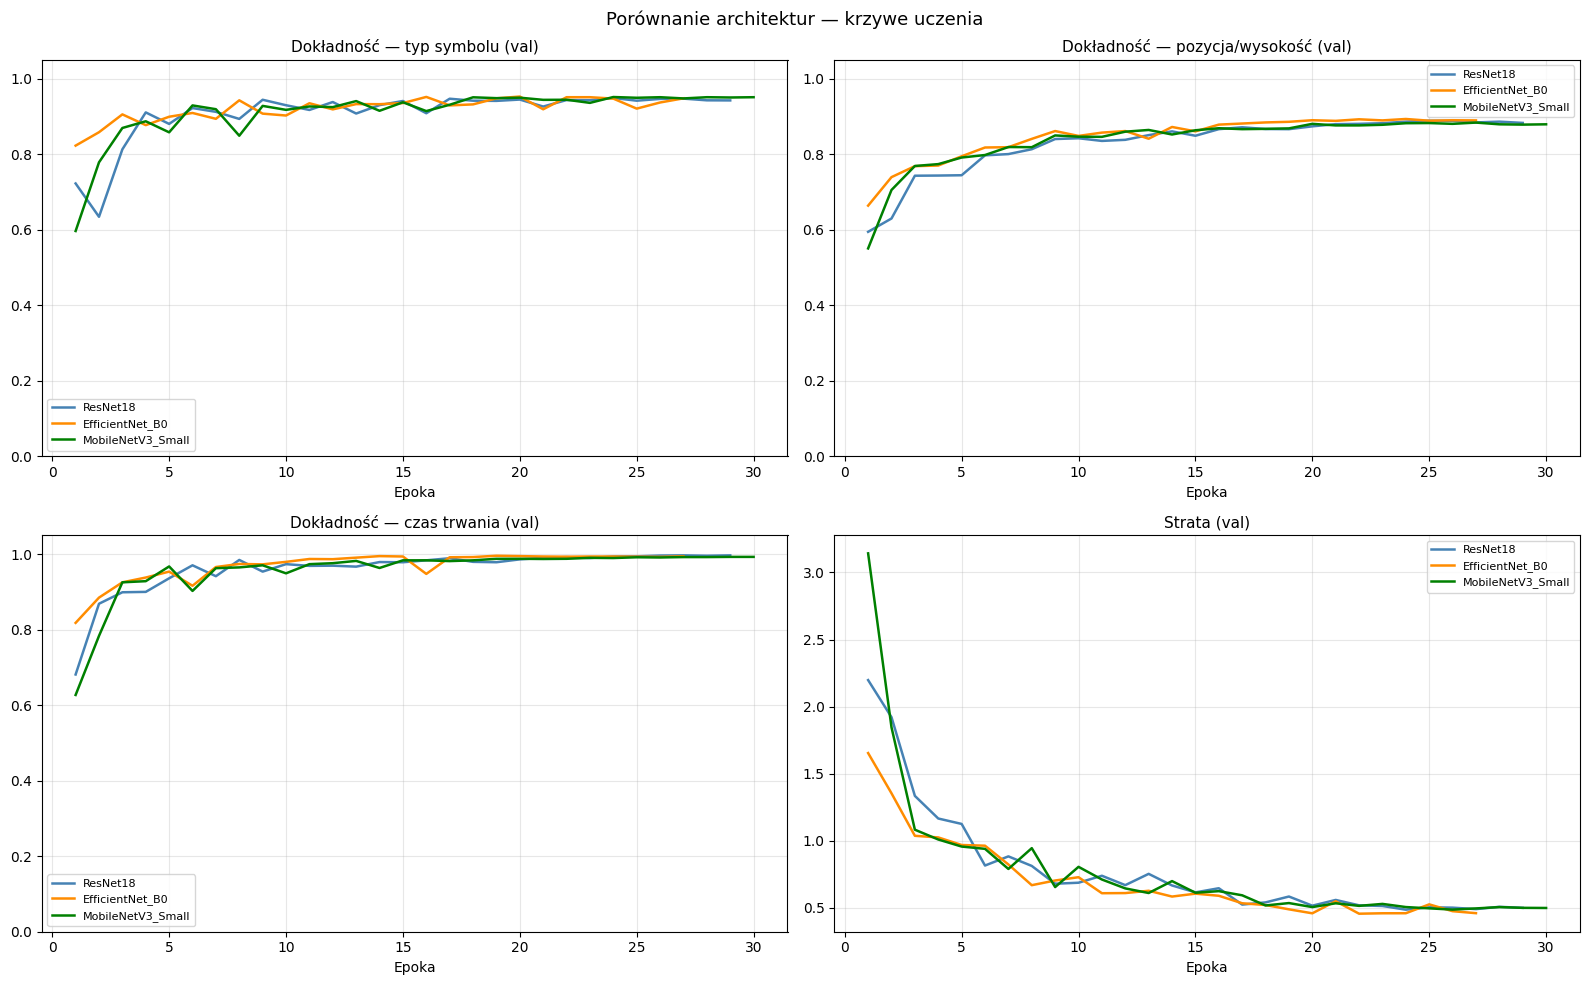

In [42]:
# ─── Tabela wyników ──────────────────────────────────────────────────────────

print(f"{'Model':<25} {'Params':>10} {'TypeAcc':>9} {'PosAcc':>9} {'DurAcc':>9}"
      f" {'ValLoss':>9} {'Czas[s]':>9}")

for name in MODELS_TO_RUN:
    res = all_results[name]
    h   = all_histories[name]
    best_ep = h['val_loss'].index(min(h['val_loss']))
    print(f"{name:<25} {res['n_params']:>10,} {res['val_type_acc']:>9.4f}"
          f" {h['val_pos_acc'][best_ep]:>9.4f} {h['val_dur_acc'][best_ep]:>9.4f}"
          f" {res['val_loss']:>9.4f} {res['train_time']:>9.1f}")


COLORS = ['steelblue', 'darkorange', 'green', 'red']

# ─── Krzywe uczenia ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (metric, title) in zip(axes.flatten(), [
    ('val_type_acc', 'Dokładność — typ symbolu (val)'),
    ('val_pos_acc',  'Dokładność — pozycja/wysokość (val)'),
    ('val_dur_acc',  'Dokładność — czas trwania (val)'),
    ('val_loss',     'Strata (val)'),
]):
    for name, color in zip(MODELS_TO_RUN, COLORS):
        vals = all_histories[name][metric]
        ax.plot(range(1, len(vals) + 1), vals, label=name, color=color, linewidth=1.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoka')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    if metric != 'val_loss':
        ax.set_ylim(0, 1.05)

plt.suptitle('Porównanie architektur — krzywe uczenia', fontsize=13)
plt.tight_layout()
plt.show()


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3136725863.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS_TO_RUN, rotation=20, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3136725863.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS_TO_RUN, rotation=20, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3136725863.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS_TO_RUN, rotation=20, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3136725863.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

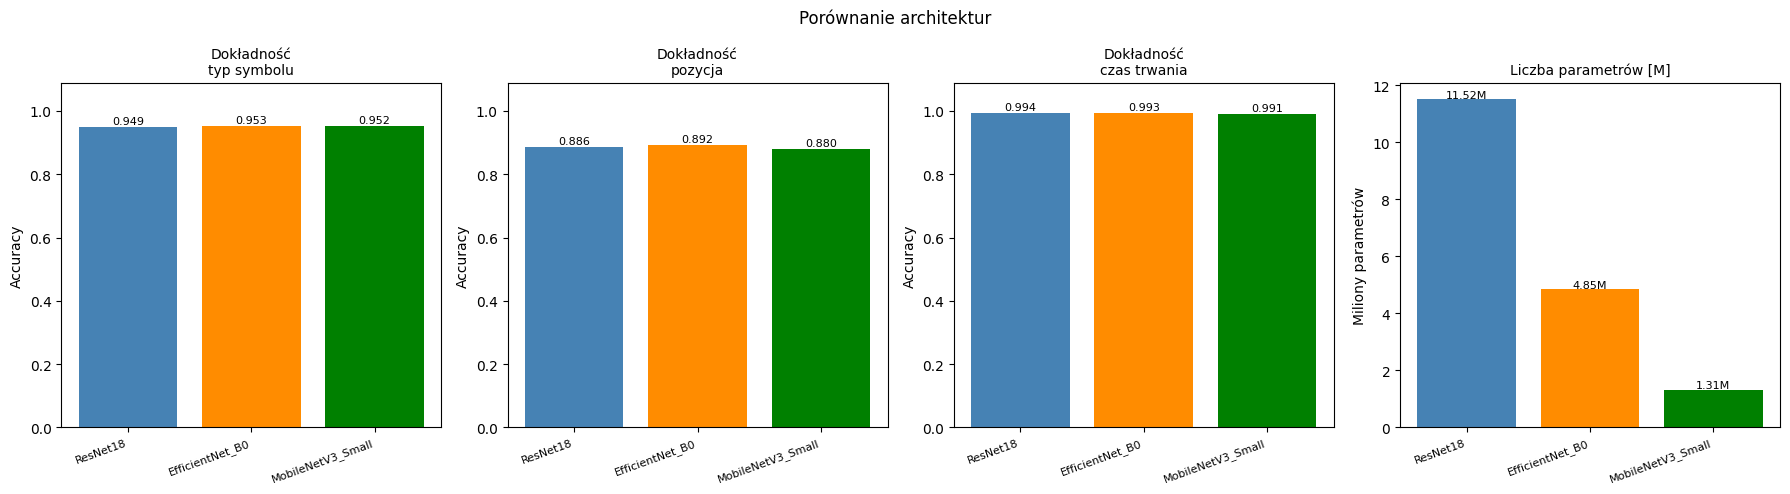

In [33]:
# ─── Wykresy słupkowe: dokładność i złożoność ────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

bar_cfg = [
    ('val_type_acc', 'Dokładność\ntyp symbolu'),
    ('val_pos_acc',  'Dokładność\npozycja'),
    ('val_dur_acc',  'Dokładność\nczas trwania'),
]

for ax, (metric, title) in zip(axes[:3], bar_cfg):
    vals = []
    for name in MODELS_TO_RUN:
        if metric == 'val_type_acc':
            vals.append(all_results[name]['val_type_acc'])
        else:
            h   = all_histories[name]
            ep  = h['val_loss'].index(min(h['val_loss']))
            vals.append(h[metric][ep])
    bars = ax.bar(MODELS_TO_RUN, vals, color=COLORS[:len(MODELS_TO_RUN)])
    ax.set_ylim(0, 1.09)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Accuracy')
    ax.set_xticklabels(MODELS_TO_RUN, rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=8)

# Liczba parametrów
ax = axes[3]
params = [all_results[n]['n_params'] / 1e6 for n in MODELS_TO_RUN]
bars = ax.bar(MODELS_TO_RUN, params, color=COLORS[:len(MODELS_TO_RUN)])
ax.set_title('Liczba parametrów [M]', fontsize=10)
ax.set_ylabel('Miliony parametrów')
ax.set_xticklabels(MODELS_TO_RUN, rotation=20, ha='right', fontsize=8)
for bar, val in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05, f'{val:.2f}M', ha='center', fontsize=8)

plt.suptitle('Porównanie architektur', fontsize=12)
plt.tight_layout()
plt.show()


## Szczegółowa analiza najlepszego modelu

Najlepszy model: EfficientNet_B0  (val_type_acc=0.9527)


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\166740662.py:26: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)


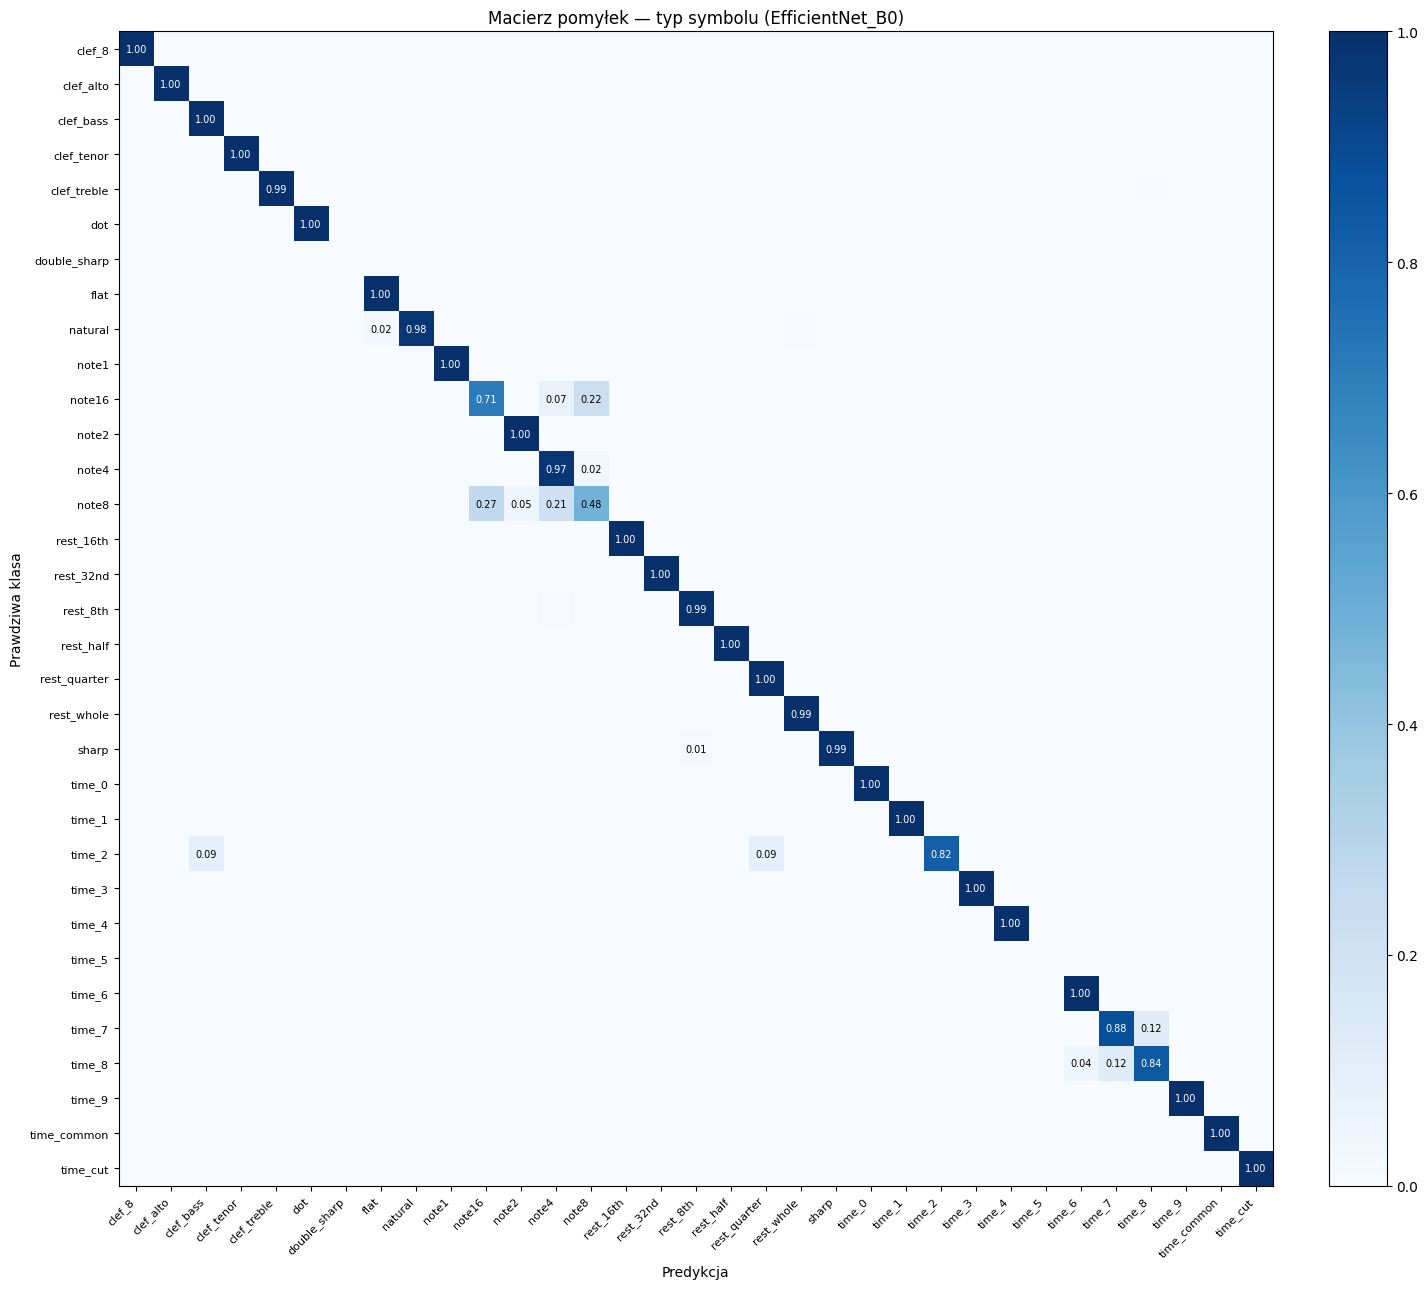

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\166740662.py:26: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)


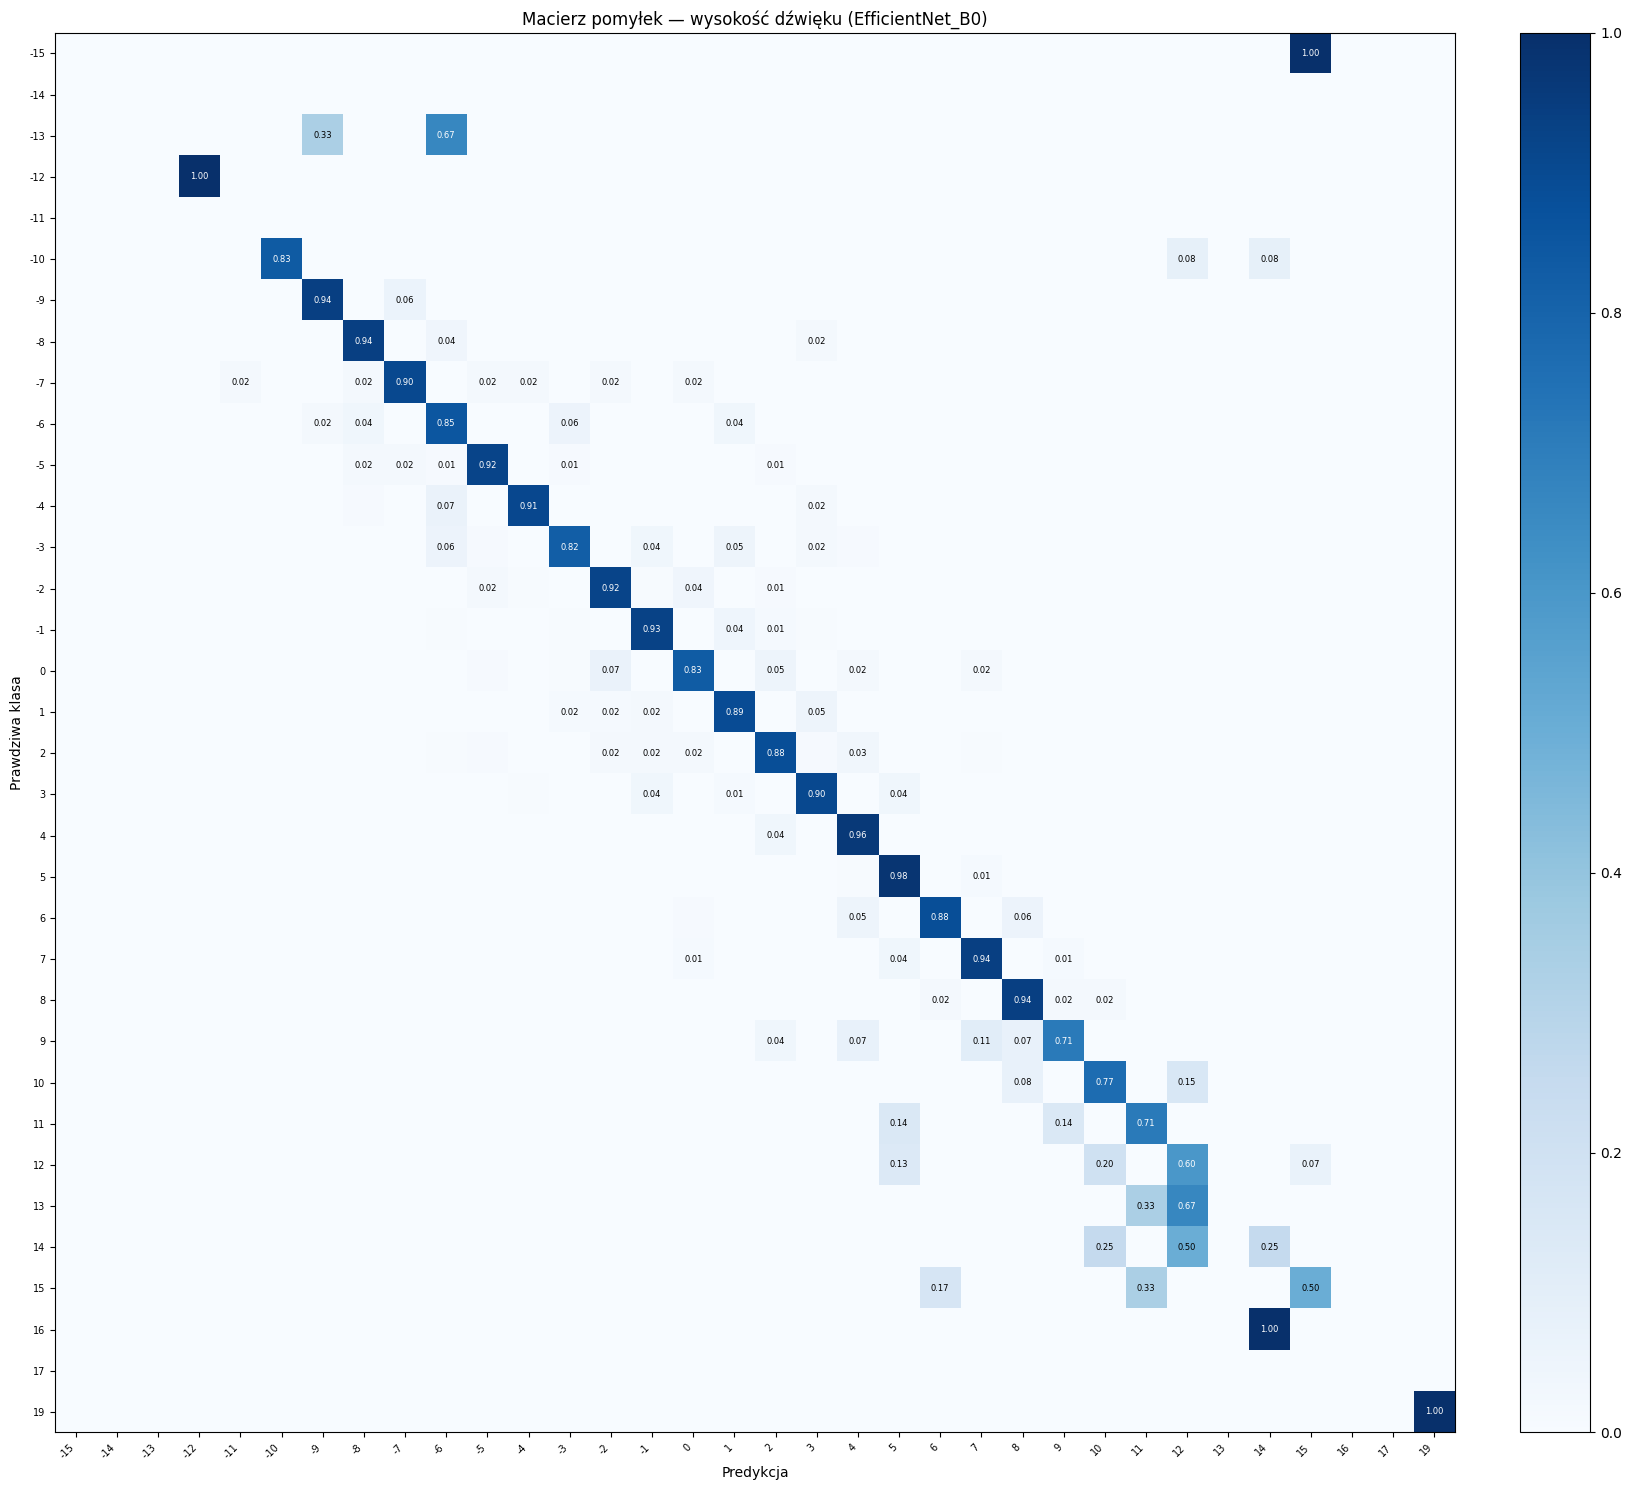

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\166740662.py:26: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)


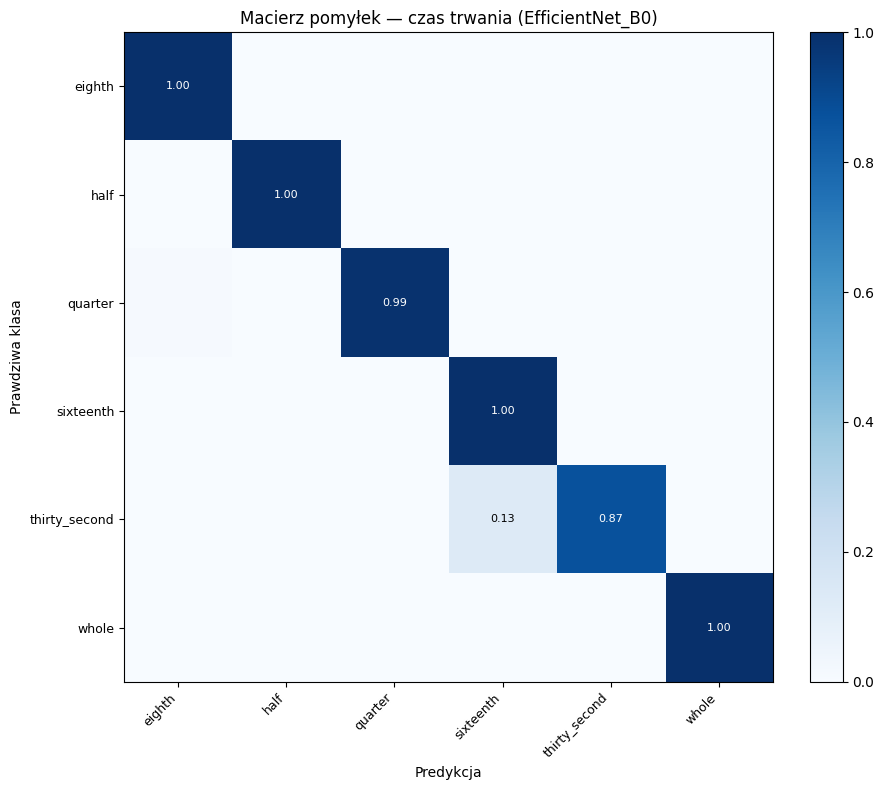


=== EfficientNet_B0: Raport klasyfikacji — typ symbolu ===


ValueError: Number of classes, 31, does not match size of target_names, 33. Try specifying the labels parameter

In [34]:
def collect_preds(model):
    """Zbiera predykcje wszystkich trzech głowic na zbiorze walidacyjnym."""
    tp, tt, pp, pt_, dp, dt_ = [], [], [], [], [], []
    model.eval()
    with torch.no_grad():
        for x, tl, pl, dl in val_loader:
            ot, op, od = model(x.to(DEVICE))
            tp.extend(ot.argmax(1).cpu().numpy())
            tt.extend(tl.numpy())
            mask_p = pl != NO_POS_LABEL
            if mask_p.sum() > 0:
                pp.extend(op.argmax(1).cpu().numpy()[mask_p.numpy()])
                pt_.extend(pl.numpy()[mask_p.numpy()])
            mask_d = dl != NO_DUR_LABEL
            if mask_d.sum() > 0:
                dp.extend(od.argmax(1).cpu().numpy()[mask_d.numpy()])
                dt_.extend(dl.numpy()[mask_d.numpy()])
    return (np.array(tp), np.array(tt),
            np.array(pp), np.array(pt_),
            np.array(dp), np.array(dt_))


def plot_cm(cm, labels, title, figsize=(13, 11), fs=7):
    fig, ax = plt.subplots(figsize=figsize)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_n = np.divide(cm.astype(float), row_sums, where=row_sums != 0)
    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=fs)
    ax.set_yticklabels(labels, fontsize=fs)
    ax.set_xlabel('Predykcja'); ax.set_ylabel('Prawdziwa klasa'); ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = cm_n[i, j]
            if v > 0.01:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=max(4, fs - 1), color='white' if v > 0.5 else 'black')
    plt.tight_layout()
    plt.show()


# Najlepszy model wg val_type_acc
best_name  = max(all_results, key=lambda n: all_results[n]['val_type_acc'])
best_model = all_models[best_name]
print(f"Najlepszy model: {best_name}  "
      f"(val_type_acc={all_results[best_name]['val_type_acc']:.4f})")

type_pred, type_true, pos_pred, pos_true, dur_pred, dur_true = collect_preds(best_model)

# 1. Typ symbolu
cm_type = confusion_matrix(type_true, type_pred, labels=list(range(NUM_TYPES)))
plot_cm(cm_type, TYPE_CLASSES,
        f'Macierz pomyłek — typ symbolu ({best_name})', figsize=(15, 13), fs=8)

# 2. Pozycja / wysokość dźwięku
pos_labels = [str(p) for p in valid_pos]
cm_pos = confusion_matrix(pos_true, pos_pred, labels=list(range(NUM_POS)))
plot_cm(cm_pos, pos_labels,
        f'Macierz pomyłek — wysokość dźwięku ({best_name})', figsize=(17, 15), fs=7)

# 3. Czas trwania
dur_idx   = sorted(set(dur_true) | set(dur_pred))
dur_names = [DUR_CLASSES[i] for i in dur_idx]
cm_dur    = confusion_matrix(dur_true, dur_pred, labels=dur_idx)
plot_cm(cm_dur, dur_names,
        f'Macierz pomyłek — czas trwania ({best_name})', figsize=(10, 8), fs=9)

print(f"\n=== {best_name}: Raport klasyfikacji — typ symbolu ===")
print(classification_report(type_true, type_pred, target_names=TYPE_CLASSES, zero_division=0))


## Dokładność per klasa — wszystkie modele

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3892583844.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3892583844.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3892583844.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)


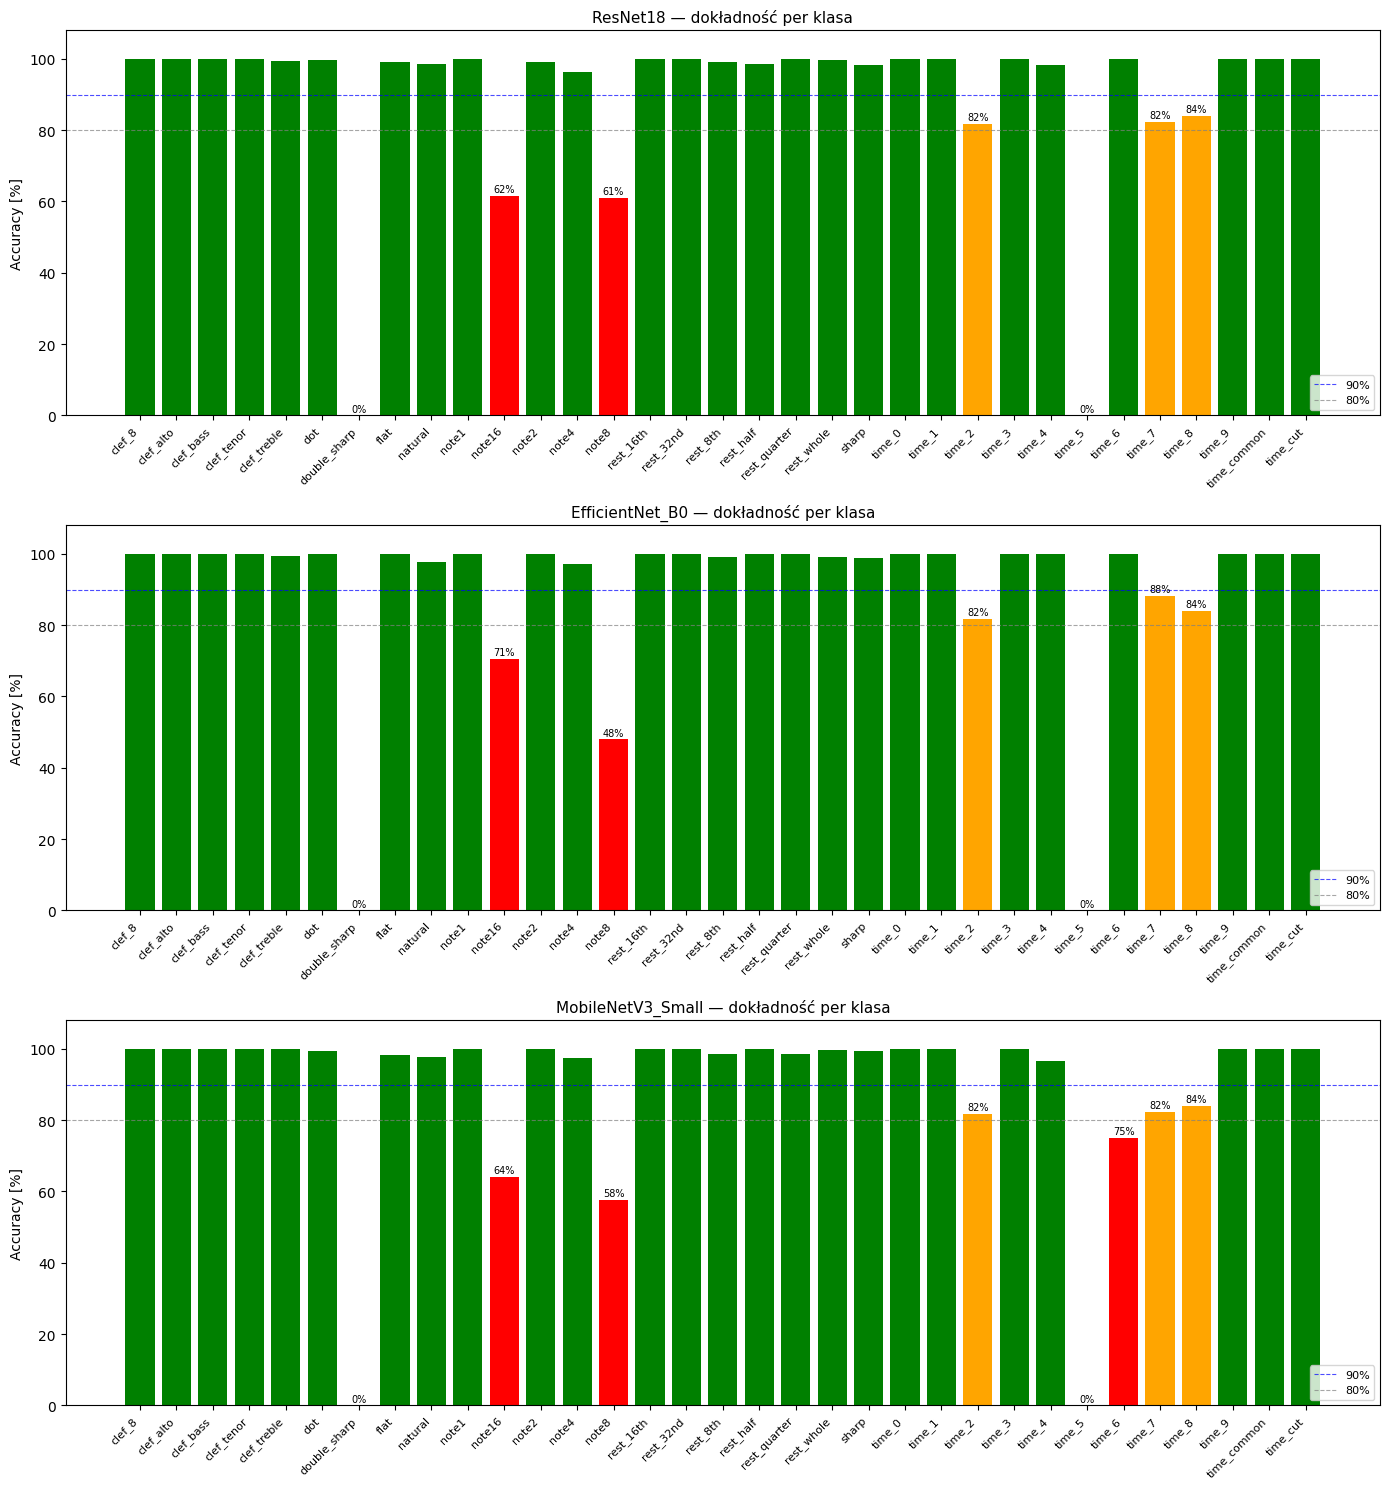

In [35]:
n_models = len(MODELS_TO_RUN)
fig, axes = plt.subplots(n_models, 1, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, MODELS_TO_RUN):
    tp, tt, *_ = collect_preds(all_models[name])
    cm = confusion_matrix(tt, tp, labels=list(range(NUM_TYPES)))
    acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    bar_colors = ['green' if a >= 0.9 else 'orange' if a >= 0.8 else 'red' for a in acc]
    ax.bar(TYPE_CLASSES, acc * 100, color=bar_colors)
    ax.axhline(90, color='blue',  linestyle='--', alpha=0.7, linewidth=0.8, label='90%')
    ax.axhline(80, color='gray',  linestyle='--', alpha=0.7, linewidth=0.8, label='80%')
    ax.set_title(f"{name} — dokładność per klasa", fontsize=11)
    ax.set_ylabel('Accuracy [%]'); ax.set_ylim(0, 108)
    ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8, loc='lower right')
    for i, (bar, val) in enumerate(zip(ax.patches, acc)):
        if val < 0.95:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1, f'{val:.0%}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()


Wczytano: MusicCNN_zapisany  (33 typów, 34 pozycji)


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3746739649.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3746739649.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3746739649.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18864\3746739649.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedL

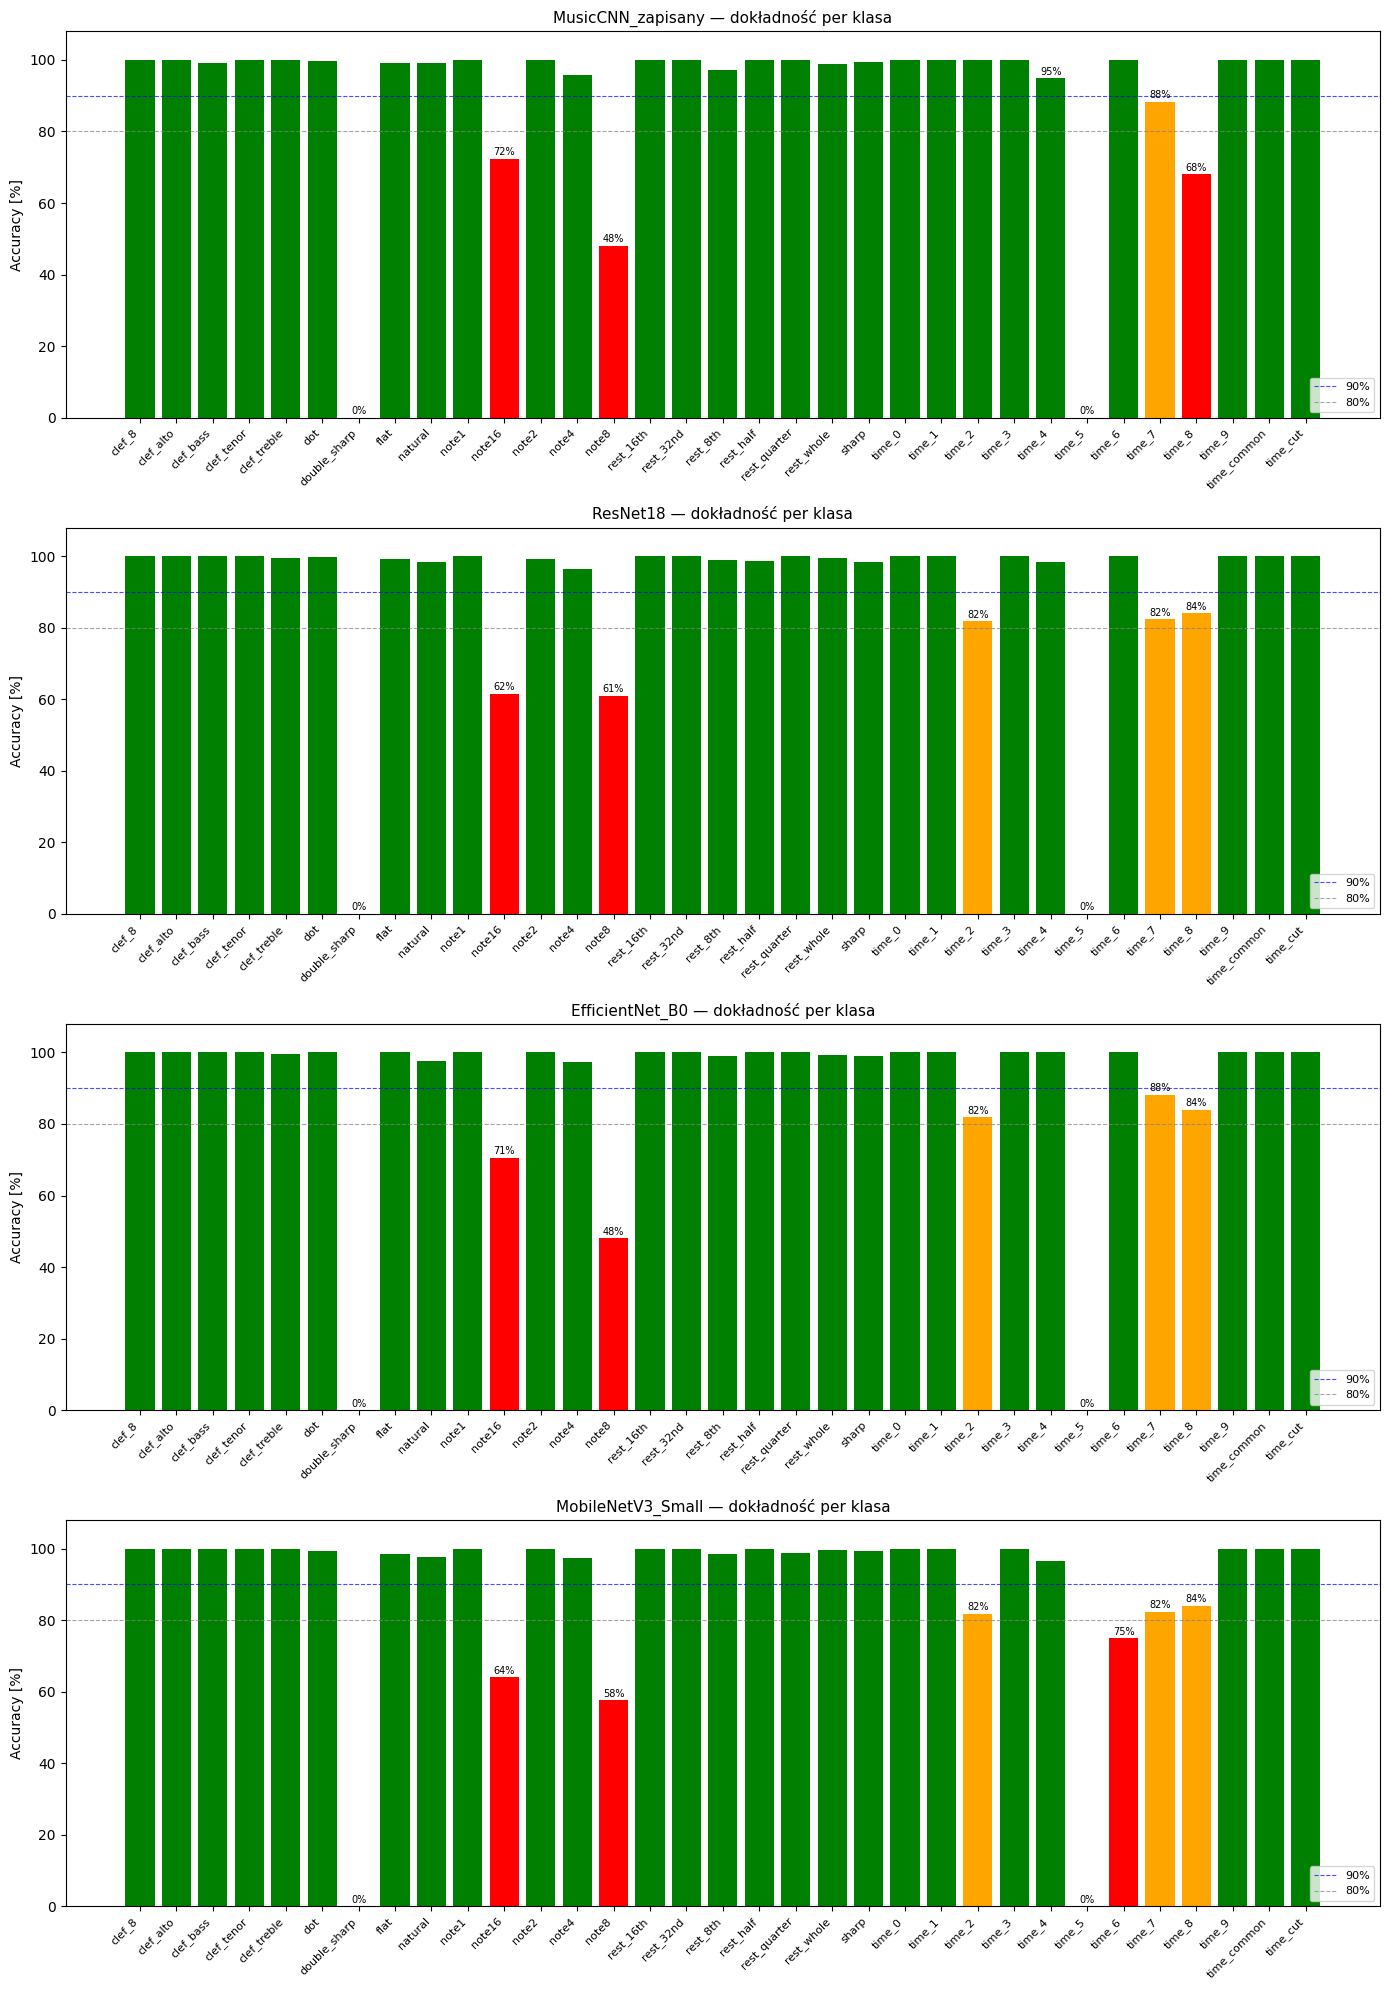

In [40]:
# ── Wczytaj zapisany model ───────────────────────────────────────────────────
ckpt_saved = torch.load("best_model_.pth",
                        map_location=DEVICE, weights_only=False)

saved_model = MusicCNN(
    ckpt_saved['NUM_TYPES'],
    ckpt_saved['NUM_POS'],
    ckpt_saved['NUM_DUR'],
).to(DEVICE)
saved_model.load_state_dict(ckpt_saved['model_state_dict'])
saved_model.eval()

SAVED_NAME = 'MusicCNN_zapisany'
all_models[SAVED_NAME] = saved_model
print(f"Wczytano: {SAVED_NAME}  "
      f"({ckpt_saved['NUM_TYPES']} typów, {ckpt_saved['NUM_POS']} pozycji)")

# ── Wykres per klasa ─────────────────────────────────────────────────────────
# Możesz dać samo [SAVED_NAME] albo razem z pozostałymi modelami
models_to_plot = [SAVED_NAME] + MODELS_TO_RUN   # <-- zmień wg potrzeb

n_models = len(models_to_plot)
fig, axes = plt.subplots(n_models, 1, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, models_to_plot):
    tp, tt, *_ = collect_preds(all_models[name])
    cm = confusion_matrix(tt, tp, labels=list(range(NUM_TYPES)))
    acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    bar_colors = ['green' if a >= 0.9 else 'orange' if a >= 0.8 else 'red' for a in acc]
    ax.bar(TYPE_CLASSES, acc * 100, color=bar_colors)
    ax.axhline(90, color='blue', linestyle='--', alpha=0.7, linewidth=0.8, label='90%')
    ax.axhline(80, color='gray', linestyle='--', alpha=0.7, linewidth=0.8, label='80%')
    ax.set_title(f"{name} — dokładność per klasa", fontsize=11)
    ax.set_ylabel('Accuracy [%]'); ax.set_ylim(0, 108)
    ax.set_xticklabels(TYPE_CLASSES, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8, loc='lower right')
    for bar, val in zip(ax.patches, acc):
        if val < 0.95:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1, f'{val:.0%}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

## Szczegółowe krzywe uczenia per model

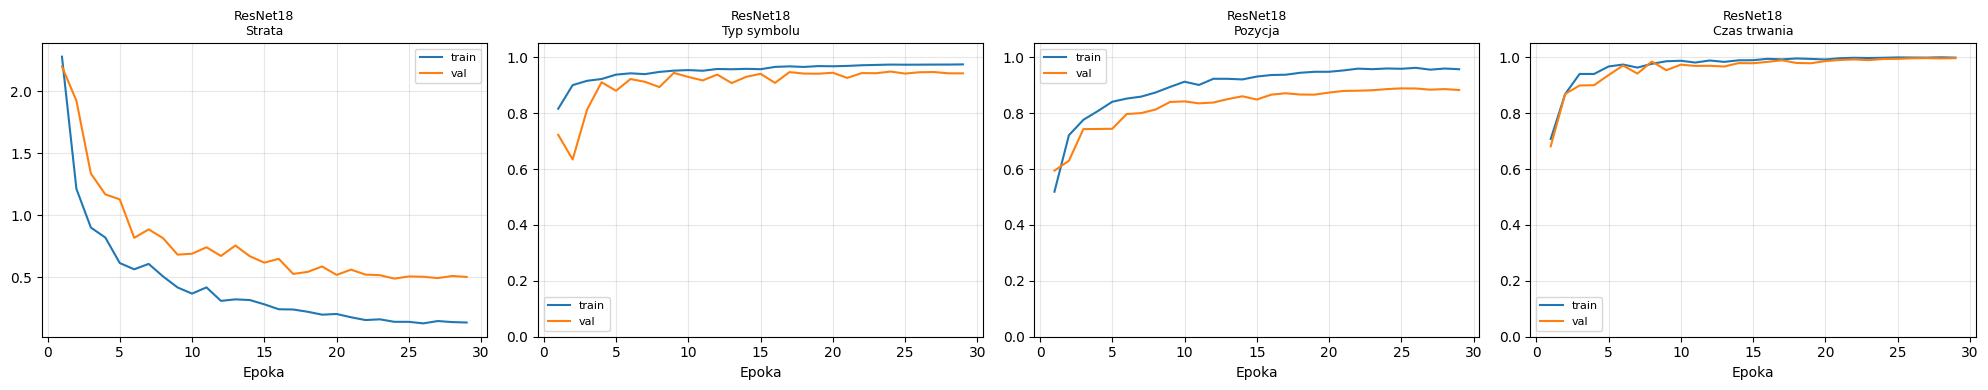

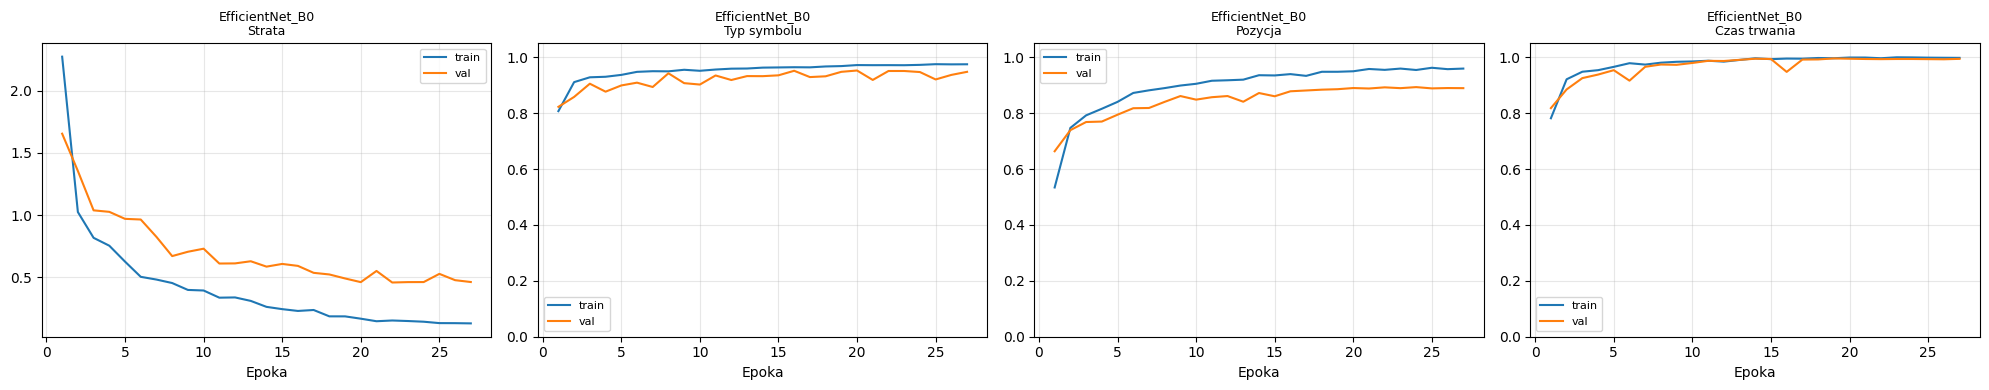

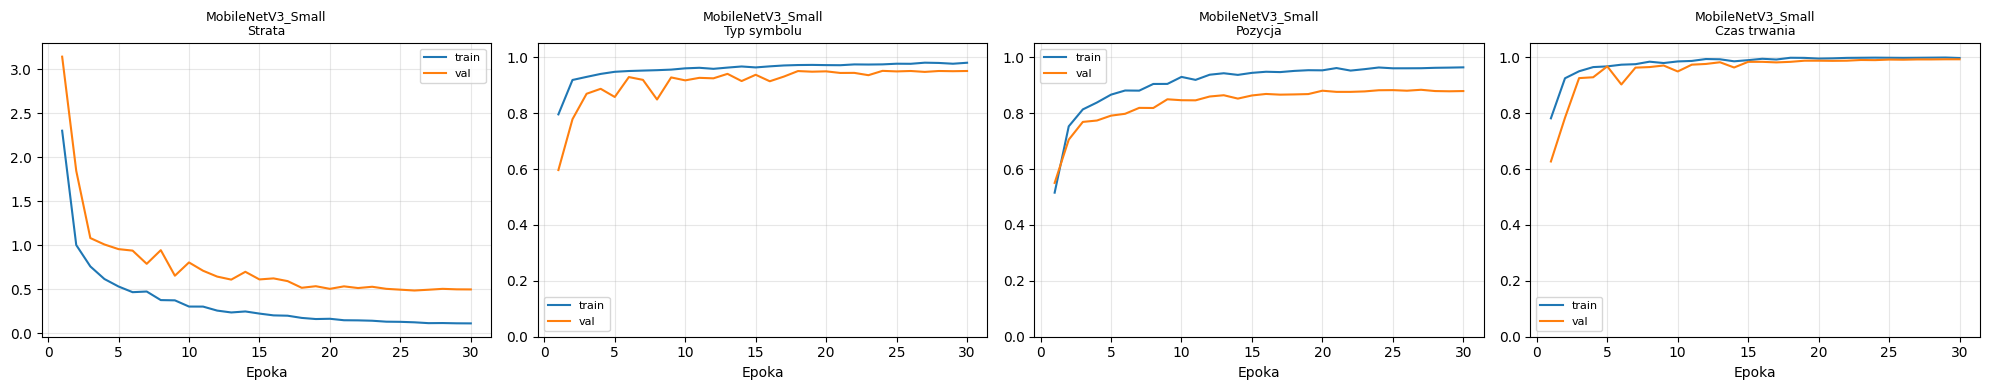

In [36]:
for name in MODELS_TO_RUN:
    h = all_histories[name]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, (tr_key, val_key, title) in zip(axes, [
        ('loss',     'val_loss',     'Strata'),
        ('type_acc', 'val_type_acc', 'Typ symbolu'),
        ('pos_acc',  'val_pos_acc',  'Pozycja'),
        ('dur_acc',  'val_dur_acc',  'Czas trwania'),
    ]):
        epochs_range = range(1, len(h[tr_key]) + 1)
        ax.plot(epochs_range, h[tr_key],  label='train', linewidth=1.5)
        ax.plot(epochs_range, h[val_key], label='val',   linewidth=1.5)
        ax.set_title(f'{name}\n{title}', fontsize=9)
        ax.set_xlabel('Epoka')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        if tr_key != 'loss':
            ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
